In [1]:
import numpy as np
import matplotlib.pyplot as plt
import prn

# Setup

In [2]:
x = np.fromfile("gpssim.bin", dtype=np.int8)
# x = np.sign(x, dtype=np.int8)

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)
x = x / np.max(np.abs(x))

f_s = 2600000 # From `gps-sdr-sim`

# Acquisition

In [3]:
N = 2 ** 13
doppler = 10e3 # Max doppler shift in a single direction
bin_size = f_s / N

print(f"Searching {1e3*N/f_s:0.2f}ms period")
print(f"{bin_size:0.1f}Hz frequency bins")

# Pre compute FFT since it's the same for every iteration
X = np.fft.fft(x[0:N]).conj()

# sv, doppler shift (Hz), code phase (samples)
results = []

for sv in range(1, 33):
    # FFT of PRN
    Y = np.fft.fft(prn.sample(sv, f_s, N))

    # Calculate frequency bins
    shifts = np.arange(-int(doppler/bin_size), int(doppler/bin_size)+1)
    shift_freqs = shifts * bin_size
    z_arr = np.zeros((len(shifts), N))

    # Iterate through frequency shifts
    for i, shift in enumerate(shifts):
        Z = X * np.roll(Y, shift)

        z = np.fft.ifft(Z)
        z = np.abs(z)
        z_arr[i] = z

    z_arr = z_arr[:, 0:int(f_s/1e3)] # Only look at first cycle of code
    shift, phase = np.unravel_index(np.argmax(z_arr), z_arr.shape) # Get freq and phase of max
    ratio = z_arr[shift, phase] / np.mean(z_arr[shift]) # Calculate ratio of max to average

    # If ratio is high enough, it's probably a real signal
    if ratio > 6:
        print(f"SV: {sv}, Doppler shift: {shift_freqs[shift]:0.2f}Hz, Code sample phase: {phase}, ratio: {ratio:0.1f}")
        results.append([sv, shift_freqs[shift], phase])

Searching 3.15ms period
317.4Hz frequency bins
SV: 3, Doppler shift: -952.15Hz, Code sample phase: 1308, ratio: 13.0
SV: 4, Doppler shift: 2856.45Hz, Code sample phase: 2385, ratio: 9.1
SV: 9, Doppler shift: 3491.21Hz, Code sample phase: 768, ratio: 15.0
SV: 16, Doppler shift: 2221.68Hz, Code sample phase: 1646, ratio: 25.4
SV: 26, Doppler shift: -317.38Hz, Code sample phase: 1186, ratio: 21.4
SV: 28, Doppler shift: -2221.68Hz, Code sample phase: 720, ratio: 11.3
SV: 29, Doppler shift: -634.77Hz, Code sample phase: 2120, ratio: 11.6
SV: 31, Doppler shift: -1269.53Hz, Code sample phase: 2393, ratio: 16.7
SV: 32, Doppler shift: -3173.83Hz, Code sample phase: 1948, ratio: 6.6


# Tracking

Stolen and modified from https://github.com/psas/gps/blob/master/Tracking.py

In [4]:
# Loop filter parameters
code_B_L = 2
code_zeta = 0.7
code_gain = 1
carrier_B_L = 25
carrier_zeta = 0.7
carrier_gain = 0.25
T = 0.001

code_length = f_s / 1e3 # Number of samples per cycle of entire code (1ms)

In [5]:
def calcLoopCoef(B_L: int, zeta: float, gain: float, T: float):
    '''
    Calculates the loop coefficients tau1 and tau2. 

    This process is discussed in sections 7.1-7.3 of Borre.
    '''
    # Solve for the natural frequency
    Wn = B_L*8*zeta / (4*zeta**2 + 1)

    # Solve for tau1 and tau2
    tau1 = gain / (Wn * Wn)
    tau2 = 2 * zeta / Wn

    coeff1 = tau2/tau1
    coeff2 = T/tau1

    return coeff1, coeff2

In [6]:
def track(x: np.ndarray, f_s: float, sv: int, f_carrier: float, code_phase: int):
    """_summary_

    Args:
        x (np.ndarray): Samples to be process
        f_s (float): Sampling frequency
        sv (int): SV number (of specific satellite)
        f_carrier (float): Carrier frequency found during acquisition
        code_phase (int): Code phase found during acquisition
    """

    # Calculate filter coefficient values for code loop
    code_C1, code_C2 = calcLoopCoef(code_B_L, code_zeta, code_gain, T)

    # Calculate filter coefficient values for carrier loop
    carrier_C1, carrier_C2 = calcLoopCoef(carrier_B_L, carrier_zeta, carrier_gain, T)

    codeFreq = 1.023e6
    ca_code = np.array(prn.generate(sv))
    # No idea why this stuff is needed
    ca_code = np.append(ca_code, ca_code[0])
    ca_code = np.insert(ca_code, 0, ca_code[len(ca_code) - 2])
    # ca_code_samples = prn.sample(sv, f_s, code_length)

    # Residual code/carrier phase
    remCodePhase = 0.0

    # define residual carrier phase
    remCarrPhase  = 0.0

    # code tracking loop parameters
    oldCodeNco   = 0.0
    oldCodeError = 0.0

    # carrier/Costas loop parameters
    oldCarrNco   = 0.0
    oldCarrError = 0.0

    dataPosition = 0

    carrFreq = f_carrier

    # Might want to make these configurable, idk
    ms = int(np.floor(len(x) * 1e3 / f_s))
    codeLength = 1023
    earlyLateSpacing = 0.5
    chippingRate = 1.023e6

    # Arrays to store results
    arr_pll_discr = np.zeros(ms)
    arr_carr_freq = np.zeros(ms)
    arr_code_freq = np.zeros(ms)
    arr_ip = np.zeros(ms)
    arr_qp = np.zeros(ms)

    # Process the requested number of code periods (num of ms to process)
    for loopCount in range(0, ms):
        # Update the phasestep based on code freq (variable) and
        # sampling frequency (fixed)
        codePhaseStep = np.real(codeFreq / f_s)

        blksize = int(np.ceil((codeLength-remCodePhase) / codePhaseStep))

        # Read in the appropriate number of samples to process this
        # iteration
        rawSignal = x[code_phase + dataPosition:code_phase + dataPosition + blksize]
        dataPosition = dataPosition + blksize

        # Handle last block
        if len(rawSignal) != blksize:
            if len(rawSignal) == 0:
                break
            blksize = len(rawSignal)

        # TODO: should this use samples instead?
        # Reference code index
        tcode = np.linspace(remCodePhase,((blksize-1)*codePhaseStep+remCodePhase) + codePhaseStep,blksize,endpoint=False)

        # Generate Early CA Code
        earlyCode = ca_code[np.ceil(tcode - earlyLateSpacing).astype(int)]

        # Generate Late CA Code
        lateCode = ca_code[np.ceil(tcode + earlyLateSpacing).astype(int)]

        # Generate Prompt CA Code
        promptCode = ca_code[np.ceil(tcode).astype(int)]

        # Figure out remaining code phase (uses tcode from Prompt CA Code generation):
        remCodePhase = (tcode[blksize-1]) - 1023.00
        if abs(remCodePhase) > codePhaseStep:
            remCodePhase = np.sign(remCodePhase)*codePhaseStep
        else:
            remCodePhase = 0

        # Generate the carrier frequency to mix the signal to baseband
        time = np.arange(blksize+1)/f_s

        # Get the argument to sin/cos functions
        trigarg = carrFreq * 2 * np.pi * time + remCarrPhase

        # Carry the leftover phase to the next argument by looking at the last element
        remCarrPhase = trigarg[blksize] % (2 * np.pi)

        # First mix to baseband
        basebandSignal = rawSignal * np.exp(1j*trigarg[0:blksize])

        # Now get early, late, and prompt values for each
        iqEarly = earlyCode * basebandSignal
        iqPrompt = promptCode * basebandSignal
        iqLate = lateCode * basebandSignal
        I_E = np.sum(iqEarly.real)
        Q_E = np.sum(iqEarly.imag)
        I_P = np.sum(iqPrompt.real)
        Q_P = np.sum(iqPrompt.imag)
        I_L = np.sum(iqLate.real)
        Q_L = np.sum(iqLate.imag)

        # Find PLL error and update carrier NCO
        # Implement carrier loop discriminator (phase detector)
        carrError = np.arctan(Q_P / I_P) / (2.0 * np.pi)

        # Implement carrier loop filter and generate NCO command
        carrNco = oldCarrNco + carrier_C1 * (carrError - oldCarrError) + carrError * carrier_C2
        oldCarrNco   = carrNco
        oldCarrError = carrError

        # Modify carrier freq based on NCO command
        carrFreq = f_carrier + carrNco

        # Find DLL error and update code NCO -------------------------------------
        codeError = (np.sqrt(I_E * I_E + Q_E * Q_E) - np.sqrt(I_L * I_L + Q_L * Q_L)) /\
                    (np.sqrt(I_E * I_E + Q_E * Q_E) + np.sqrt(I_L * I_L + Q_L * Q_L))

        # Implement code loop filter and generate NCO command
        codeNco = oldCodeNco + code_C1 * (codeError - oldCodeError) + codeError * code_C2
        oldCodeNco   = codeNco
        oldCodeError = codeError

        # Modify code freq based on NCO command
        codeFreq = chippingRate - codeNco

        arr_pll_discr[loopCount] = carrError
        arr_carr_freq[loopCount] = carrFreq
        arr_code_freq[loopCount] = codeFreq
        arr_ip[loopCount] = I_P
        arr_qp[loopCount] = Q_P
    
    return arr_ip, arr_qp, arr_pll_discr, arr_carr_freq, arr_code_freq

In [7]:
# Attempt tracking
i = 2
sv = results[i][0]
f_carrier = results[i][1]
code_phase = results[i][2]*1023/(2**13)
print(code_phase, int(np.round(code_phase)))
arr_ip, arr_qp, arr_pll_discr, arr_carr_freq, arr_code_freq = track(x[0:f_s*1], f_s, sv, f_carrier, int(np.round(code_phase)))

95.90625 96


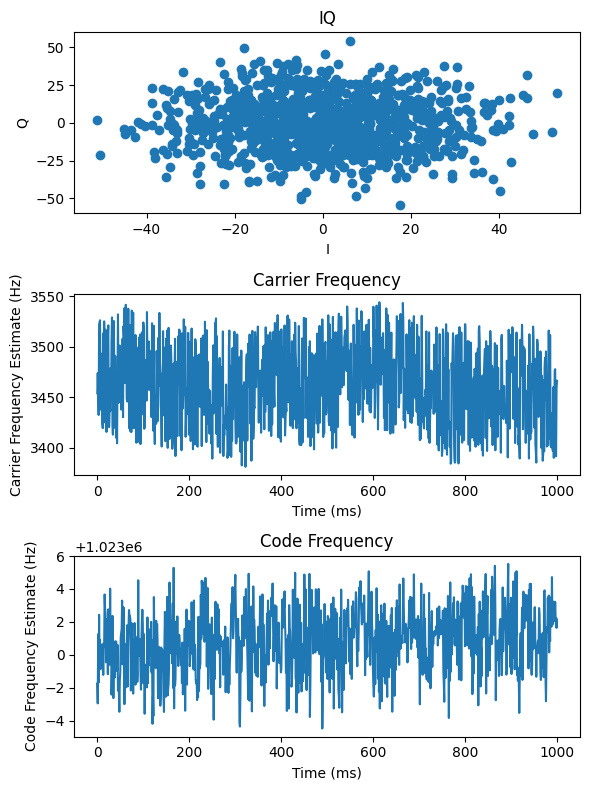

In [8]:
plt.figure(figsize=(6, 8))

plt.subplot(3, 1, 1)
plt.scatter(arr_ip, arr_qp)
plt.title("IQ")
plt.xlabel("I")
plt.ylabel("Q")

plt.subplot(3, 1, 2)
plt.plot(arr_carr_freq)
plt.title("Carrier Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Carrier Frequency Estimate (Hz)")

plt.subplot(3, 1, 3)
plt.plot(arr_code_freq)
plt.title("Code Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Code Frequency Estimate (Hz)")

plt.tight_layout()